In [2]:
%pip install wfdb numpy pandas matplotlib scipy biosppy

import wfdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import os

# Путь к твоим папкам (измени на свои)
PATH_TO_PTBXL = 'ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.1/' 
PATH_TO_NOISE = 'mit-bih-noise-stress-test-database-1.0.0/'


[notice] A new release of pip available: 22.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


In [3]:
def load_ptbxl_metadata(path):
    df = pd.read_csv(path + 'ptbxl_database.csv', index_col='ecg_id')
    # Превращаем строки со словарями в реальные словари Python
    import ast
    df.scp_codes = df.scp_codes.apply(lambda x: ast.literal_eval(x))
    return df

df = load_ptbxl_metadata(PATH_TO_PTBXL)

# Пример: выведем первые 5 записей и посмотрим на диагнозы
print(df[['scp_codes', 'report']].head())

                                       scp_codes  \
ecg_id                                             
1       {'NORM': 100.0, 'LVOLT': 0.0, 'SR': 0.0}   
2                   {'NORM': 80.0, 'SBRAD': 0.0}   
3                     {'NORM': 100.0, 'SR': 0.0}   
4                     {'NORM': 100.0, 'SR': 0.0}   
5                     {'NORM': 100.0, 'SR': 0.0}   

                                        report  
ecg_id                                          
1       sinusrhythmus periphere niederspannung  
2          sinusbradykardie sonst normales ekg  
3                   sinusrhythmus normales ekg  
4                   sinusrhythmus normales ekg  
5                   sinusrhythmus normales ekg  


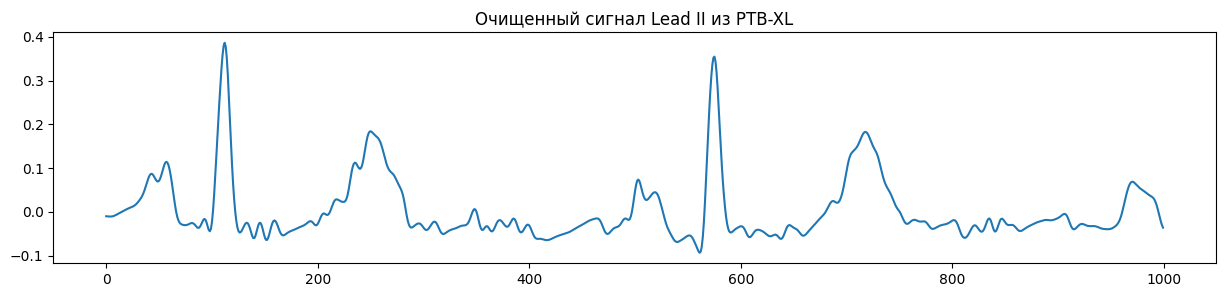

In [51]:
def get_signal_lead_ii(record_path, sampling_rate=500):
    # 1. Читаем сигнал (Lead II)
    record, fields = wfdb.rdsamp(record_path, channels=[1]) 
    sig = record[:, 0]
    
    # 2. Очистка сигнала (Advanced Bandpass 0.5 - 45 Hz)
    # Используем SOS (Second-Order Sections) для лучшей стабильности
    from scipy import signal as sp_signal
    sos = sp_signal.butter(3, [0.5, 45], btype='bandpass', fs=sampling_rate, output='sos')
    filtered_sig = sp_signal.sosfiltfilt(sos, sig)
    
    return filtered_sig

# Проверка: загрузим первую запись
sample_sig = get_signal_lead_ii(PATH_TO_PTBXL + 'records500/00000/00001_hr')
plt.figure(figsize=(15, 3))
plt.plot(sample_sig[:1000]) # Показать первые 2 секунды
plt.title("Очищенный сигнал Lead II из PTB-XL")
plt.show()

Шум 'ma' успешно загружен. Длина: 650000


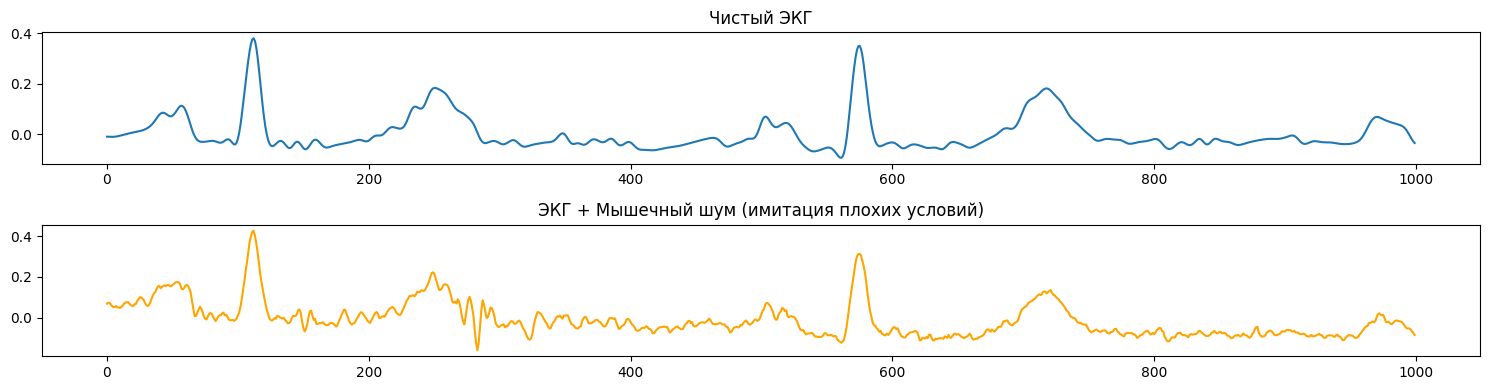

In [5]:
# Загружаем конкретный тип шума, например 'ma' (Muscle Artifact)
try:
    # Мы читаем файл 'ma' из папки nstdb
    noise_data, noise_fields = wfdb.rdsamp(os.path.join(PATH_TO_NOISE, 'ma'), channels=[0])
    noise_sig = noise_data[:, 0]
    print("Шум 'ma' успешно загружен. Длина:", len(noise_sig))
except Exception as e:
    print(f"Ошибка загрузки: {e}. Проверь, что в папке {PATH_TO_NOISE} есть файлы ma.dat и ma.hea")

def generate_noisy_sample(clean_sig, noise_source, target_snr_db):
    """
    Смешивает сигнал с шумом, исходя из заданного соотношения Сигнал/Шум (SNR) в децибелах.
    Чем ниже SNR, тем больше шума.
    """
    # Вырезаем случайный кусок шума той же длины, что и сигнал
    start = np.random.randint(0, len(noise_source) - len(clean_sig))
    noise_segment = noise_source[start : start + len(clean_sig)]
    
    # Расчет мощностей для правильного смешивания (SNR)
    sig_power = np.mean(clean_sig ** 2)
    noise_power = np.mean(noise_segment ** 2)
    
    # Вычисляем коэффициент масштабирования шума для нужного SNR
    factor = np.sqrt(sig_power / (noise_power * (10**(target_snr_db / 10))))
    
    return clean_sig + (noise_segment * factor)

# Пример: создаем очень зашумленный сигнал (SNR = 6dB)
very_noisy = generate_noisy_sample(sample_sig, noise_sig, target_snr_db=6)

plt.figure(figsize=(15, 4))
plt.subplot(2, 1, 1)
plt.plot(sample_sig[:1000])
plt.title("Чистый ЭКГ")
plt.subplot(2, 1, 2)
plt.plot(very_noisy[:1000], color='orange')
plt.title("ЭКГ + Мышечный шум (имитация плохих условий)")
plt.tight_layout()
plt.show()

In [46]:
import pandas as pd
import numpy as np
import ast
from sklearn.preprocessing import LabelEncoder

# 1. Загружаем справочник и чистим его
agg_df = pd.read_csv(PATH_TO_PTBXL + 'scp_statements.csv', index_col=0)
agg_df.index = agg_df.index.str.strip()
# Создаем словарь: Код диагноза -> Суперкласс (MI, NORM, CD и т.д.)
diag_to_super = agg_df[agg_df.diagnostic == 1]['diagnostic_class'].to_dict()

def get_superclass_final(val):
    try:
        # 1. Проверяем, не пустая ли ячейка
        if pd.isna(val): return None
        
        # 2. Если это строка, превращаем в словарь
        if isinstance(val, str):
            codes = ast.literal_eval(val)
        else:
            codes = val
            
        # 3. Ищем соответствие в справочнике
        for code in codes.keys():
            clean_code = str(code).strip()
            if clean_code in diag_to_super:
                return diag_to_super[clean_code]
    except:
        return None
    return None

# Применяем
df['super_label'] = df['scp_codes'].apply(get_superclass_final)

# Очистка и кодирование
df_clean = df.dropna(subset=['super_label']).copy()

if len(df_clean) > 0:
    le = LabelEncoder()
    df_clean['target_idx'] = le.fit_transform(df_clean['super_label'].astype(str))
    num_super_classes = len(le.classes_)
    noise_label_idx = num_super_classes
    
    print(f"✅ Успех! Найдено записей: {len(df_clean)}")
    print(f"Классы диагнозов: {list(le.classes_)}")
    print(f"Распределение:\n{df_clean['super_label'].value_counts()}")
else:
    print("❌ Все еще 0. Проверь путь PATH_TO_PTBXL и наличие данных в df['scp_codes']")

✅ Успех! Найдено записей: 21430
Классы диагнозов: ['CD', 'HYP', 'MI', 'NORM', 'STTC']
Распределение:
super_label
NORM    9528
MI      5441
STTC    2823
CD      2327
HYP     1311
Name: count, dtype: int64


In [21]:
import os

print(f"Ищем файлы в: {PATH_TO_PTBXL}")
if os.path.exists(PATH_TO_PTBXL):
    print("✅ Путь существует")
    # Смотрим, что внутри папки
    contents = os.listdir(PATH_TO_PTBXL)
    print(f"Содержимое папки: {contents}")
    
    # Проверяем наличие папки с записями (в PTB-XL это обычно 'records500')
    records_dir = os.path.join(PATH_TO_PTBXL, 'records500')
    if os.path.exists(records_dir):
        print("✅ Папка 'records500' найдена")
    else:
        print("❌ Папка 'records500' НЕ НАЙДЕНА. Проверь структуру архива.")
else:
    print("❌ Путь НЕ СУЩЕСТВУЕТ. Проверь правильность строки PATH_TO_PTBXL.")

Ищем файлы в: ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.1/
✅ Путь существует
Содержимое папки: ['example_physionet.py', 'LICENSE.txt', 'ptbxl_database.csv', 'RECORDS', 'records100', 'records500', 'scp_statements.csv', 'SHA256SUMS.txt']
✅ Папка 'records500' найдена


In [70]:
X = []
y = []
max_ecg_records = 21000 
noise_records = 5000

# 1. Сбор реальных ЭКГ
print("Загрузка ЭКГ...")
for i, (idx, row) in enumerate(df_clean.head(max_ecg_records).iterrows()):
    # выбираем путь: filename_hr или filename_lr
    if 'filename_hr' in row and pd.notna(row['filename_hr']):
        record_rel = row['filename_hr']
    elif 'filename_lr' in row and pd.notna(row['filename_lr']):
        record_rel = row['filename_lr']
    else:
        continue

    record_rel = str(record_rel).replace('\\', '/')
    record_path = os.path.join(PATH_TO_PTBXL, record_rel)

    # Если есть .dat в названии, убираем, иначе функция сама добавляет .dat
    record_path = record_path.replace('.dat', '')

    seg = get_signal_lead_ii(record_path)
    if seg is None or len(seg) < 1000:
        continue

    S = seg[:1000].reshape(1000, 1)
    S = (S - np.mean(S)) / (np.std(S) + 1e-8)
    X.append(S)
    y.append(row.target_idx)

# 2. Добавление шума (используем твой файл 'ma')
print("Генерация шума...")
for _ in range(noise_records):
    start = np.random.randint(0, len(noise_data) - 1000)
    noise_segment = noise_data[start:start+1000].reshape(1000, 1)
    # Нормализация шума
    noise_segment = (noise_segment - np.mean(noise_segment)) / (np.std(noise_segment) + 1e-8)
    X.append(noise_segment)
    y.append(noise_label_idx)

X = np.array(X)
y = np.array(y)

print(f"Итого собрано: {len(X)} сегментов.")
print(f"Распределение: {np.bincount(y)}")

Загрузка ЭКГ...
Генерация шума...
Итого собрано: 26000 сегментов.
Распределение: [2284 1273 5306 9374 2763 5000]


In [13]:
%pip install scikit-learn tensorflow

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [71]:
# Переопределяем имена классов для суперклассов + шум
class_names = ['CD', 'HYP', 'MI', 'NORM', 'STTC', 'NOISE']
num_classes_final = len(class_names) 

print(f"Теперь мы обучаем модель на {num_classes_final} классах")

Теперь мы обучаем модель на 6 классах


In [72]:
# 1. Перемешиваем индексы
indices = np.arange(len(X))
np.random.shuffle(indices)

X = X[indices]
y = y[indices]

print("Данные перемешаны! Теперь в конце массива не только шум.")

Данные перемешаны! Теперь в конце массива не только шум.


In [75]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, BatchNormalization, MaxPooling1D, Bidirectional, LSTM, Dense, Dropout
from sklearn.utils import class_weight
from tensorflow.keras.callbacks import EarlyStopping

# 1. Расчет весов для балансировки
weights = class_weight.compute_class_weight('balanced', classes=np.unique(y), y=y)
dict_weights = dict(enumerate(weights))

# РУЧНАЯ КОРРЕКТИРОВКА
# HYP — самый сложный, увеличиваем его вес в 4 раза
if 1 in dict_weights:
    dict_weights[1] *= 2.5
# CD и STTC — увеличиваем в 2 раза
if 0 in dict_weights:
    dict_weights[0] *= 1.5
if 4 in dict_weights:
    dict_weights[4] *= 2.0
# MI — увеличиваем в 1.5 раза
if 2 in dict_weights:
    dict_weights[2] *= 1.3
# NOISE и NORM оставляем как есть (или чуть уменьшаем)
if 3 in dict_weights:
    dict_weights[3] *= 1.2
if 5 in dict_weights:
    dict_weights[5] *= 0.5

print("Итоговые веса для обучения:", dict_weights)

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# 2. Архитектура
num_classes_final = len(class_names)  # включаем NOISE
model = Sequential([
    Conv1D(64, kernel_size=16, padding='same', activation='relu', input_shape=(1000, 1)),
    BatchNormalization(),
    MaxPooling1D(pool_size=4),
    
    Conv1D(128, kernel_size=7, padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling1D(pool_size=4),

    Bidirectional(LSTM(64, return_sequences=True)),
    Bidirectional(LSTM(64)),
    
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(num_classes_final, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# 3. Обучение
history = model.fit(X, y, epochs=100, batch_size=64, validation_split=0.2, class_weight=dict_weights, callbacks=[early_stop])

Итоговые веса для обучения: {0: np.float64(2.8458844133099825), 1: np.float64(8.510081173081957), 2: np.float64(1.0616911672320644), 3: np.float64(0.5547258374226585), 4: np.float64(3.1366871757751236), 5: np.float64(0.43333333333333335)}
Epoch 1/100


c:\Users\ggakl\Desktop\ecg\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


325/325 ━━━━━━━━━━━━━━━━━━━━ 26s 70ms/step - accuracy: 0.4437 - loss: 2.0457 - val_accuracy: 0.5831 - val_loss: 1.1002
Epoch 2/100
325/325 ━━━━━━━━━━━━━━━━━━━━ 22s 68ms/step - accuracy: 0.5323 - loss: 1.8793 - val_accuracy: 0.5667 - val_loss: 1.1198
Epoch 3/100
325/325 ━━━━━━━━━━━━━━━━━━━━ 22s 69ms/step - accuracy: 0.5607 - loss: 1.8107 - val_accuracy: 0.6248 - val_loss: 1.0212
Epoch 4/100
325/325 ━━━━━━━━━━━━━━━━━━━━ 23s 70ms/step - accuracy: 0.5715 - loss: 1.7725 - val_accuracy: 0.6302 - val_loss: 0.9941
Epoch 5/100
325/325 ━━━━━━━━━━━━━━━━━━━━ 23s 69ms/step - accuracy: 0.5754 - loss: 1.7531 - val_accuracy: 0.5550 - val_loss: 1.1255
Epoch 6/100
325/325 ━━━━━━━━━━━━━━━━━━━━ 23s 69ms/step - accuracy: 0.5685 - loss: 1.7370 - val_accuracy: 0.5790 - val_loss: 1.0900
Epoch 7/100
325/325 ━━━━━━━━━━━━━━━━━━━━ 23s 70ms/step - accuracy: 0.5752 - loss: 1.6918 - val_accuracy: 0.6215 - val_loss: 1.0138
Epoch 8/100
325/325 ━━━━━━━━━━━━━━━━━━━━ 23s 69ms/step - accuracy: 0.5906 - loss: 1.6691 - val_

In [58]:
print(f"Уникальные классы в y: {np.unique(y)}")
print(f"Количество имен в class_names: {len(class_names)}")

Уникальные классы в y: [0 1 2 3 4 5]
Количество имен в class_names: 24


163/163 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step
Отчет по классификации (Суперклассы):
              precision    recall  f1-score   support

          CD       0.45      0.65      0.53       468
         HYP       0.17      0.47      0.25       262
          MI       0.80      0.22      0.34      1070
        NORM       0.80      0.69      0.74      1883
        STTC       0.32      0.56      0.41       535
       NOISE       1.00      1.00      1.00       982

    accuracy                           0.62      5200
   macro avg       0.59      0.60      0.55      5200
weighted avg       0.72      0.62      0.63      5200



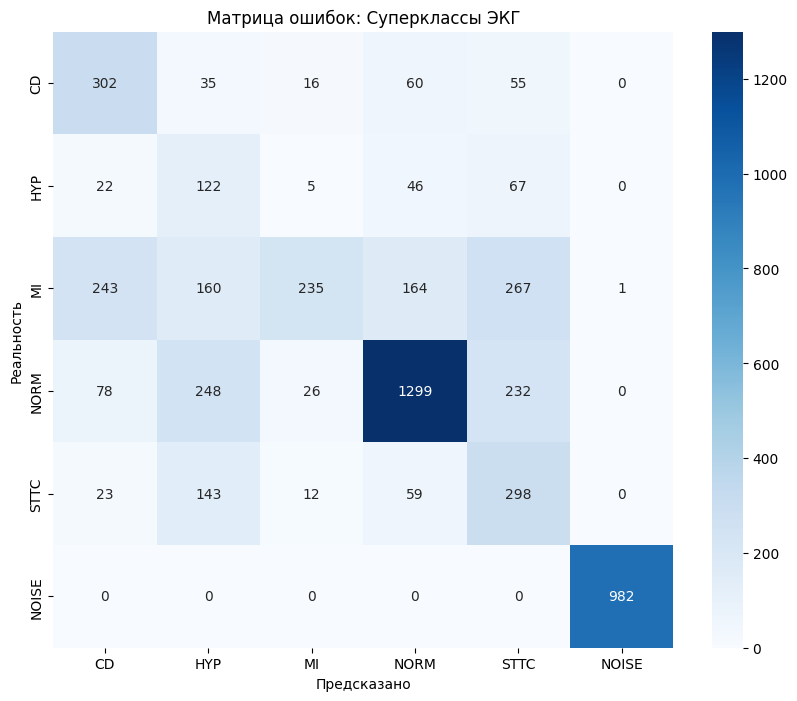

In [76]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# 1. Делаем предсказание
# X_test мы берем как последние 20% данных, так как в fit указано validation_split=0.2
split_idx = int(len(X) * 0.8)
X_val = X[split_idx:]
y_val = y[split_idx:]

y_pred_probs = model.predict(X_val)
y_pred = np.argmax(y_pred_probs, axis=1)

# 2. Печатаем отчет (используем class_names из 6 элементов)
print("Отчет по классификации (Суперклассы):")
print(classification_report(y_val, y_pred, target_names=class_names))

# 3. Матрица ошибок
cm = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.title('Матрица ошибок: Суперклассы ЭКГ')
plt.xlabel('Предсказано')
plt.ylabel('Реальность')
plt.show()

In [42]:
# Оставляем только те классы, где больше 150 примеров
counts = df['diagnostic_subclass'].value_counts()
valid_subclasses = counts[counts > 150].index.tolist()

df_smart = df[df['diagnostic_subclass'].isin(valid_subclasses)].copy()

print(f"Мы сократили количество классов до {len(valid_subclasses)} (самые надежные)")
print("Остались классы:", valid_subclasses)

Мы сократили количество классов до 13 (самые надежные)
Остались классы: ['NORM', 'IMI', 'STTC', 'AMI', 'LVH', 'LAFB/LPFB', 'NST_', 'IRBBB', 'CLBBB', 'ISCA', '_AVB', 'IVCD', 'CRBBB']


In [77]:
model.save('best_ecg_model.h5')
print("Модель сохранена для сервера!")

Модель сохранена для сервера!
